### Computer Vision In a Nutshell

#### Libraries

- `torchVision` - Base domain for CV with PyTorch
- `torchvision.datasets` - Datasets for CV with PyTorch
- `torchvision.models` - Get pre-trained models for CV with PyTorch
- `torchvision.transforms` - Transformations for CV with PyTorch

In [1]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in ".\rice-type-classification" (use force=True to force download)


In [3]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [4]:
data_df = pd.read_csv('rice-type-classification\\riceClassification.csv')
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
data_df.dropna(inplace=True)
data_df.drop('id', axis=1, inplace=True)

In [6]:
data_df.head(), data_df.shape

(   Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
 0  4537        92.229316        64.012769      0.719916        4677   
 1  2872        74.691881        51.400454      0.725553        3015   
 2  3048        76.293164        52.043491      0.731211        3132   
 3  3073        77.033628        51.928487      0.738639        3157   
 4  3693        85.124785        56.374021      0.749282        3802   
 
    EquivDiameter    Extent  Perimeter  Roundness  AspectRation  Class  
 0      76.004525  0.657536    273.085   0.764510      1.440796      1  
 1      60.471018  0.713009    208.317   0.831658      1.453137      1  
 2      62.296341  0.759153    210.012   0.868434      1.465950      1  
 3      62.551300  0.783529    210.657   0.870203      1.483456      1  
 4      68.571668  0.769375    230.332   0.874743      1.510000      1  ,
 (18185, 11))

In [7]:
original_df = data_df.copy()

for col in data_df.columns:
    data_df[col] = data_df[col] / data_df[col].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [8]:
X = np.array(data_df.iloc[:, :-1])
y = np.array(data_df.iloc[:, -1])


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [11]:
X_train.shape, X_test.shape, X_val.shape

((12729, 10), (2728, 10), (2728, 10))

#### Turning numpy data to PyTorch tensors using class torch.utils.data.Dataset

In [12]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


In [13]:
training_data = dataset(X_train, y_train)
test_data = dataset(X_test, y_test)
validation_data = dataset(X_val, y_val)

#### Using DataLoader to specify the batch size

**Properties**
- Devides the data into specified batches for the training of NN
- If the data length is 100 and `batch_size=30` then it devides into 3 groups of 30 and leaving last 10 for other group. To avoid we can specify `drop_last=True`
- `num_workers: int` - Specify how many batches should be loaded at once 

In [14]:
train_dataloader = DataLoader(training_data, batch_size=8, shuffle=True) 
test_dataloader = DataLoader(test_data, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=8, shuffle=True)

In [15]:
for x, Y in train_dataloader:
    print(x)
    print("==========")
    print(Y)
    break


tensor([[0.5822, 0.7660, 0.6713, 0.9503, 0.5548, 0.7630, 0.6338, 0.6409, 0.7772,
         0.6474],
        [0.8710, 0.8609, 0.8753, 0.9195, 0.8274, 0.9333, 0.7381, 0.7412, 0.8695,
         0.5580],
        [0.8833, 0.8584, 0.8893, 0.9148, 0.8367, 0.9398, 0.9048, 0.7839, 0.7883,
         0.5476],
        [0.5163, 0.7384, 0.6118, 0.9596, 0.4915, 0.7185, 0.5638, 0.6102, 0.7603,
         0.6848],
        [0.6746, 0.9400, 0.6284, 0.9863, 0.6395, 0.8214, 0.7244, 0.7381, 0.6791,
         0.8487],
        [0.9336, 0.8837, 0.9161, 0.9146, 0.8828, 0.9662, 0.9254, 0.7595, 0.8876,
         0.5473],
        [0.6716, 0.8498, 0.7001, 0.9605, 0.6445, 0.8195, 0.5535, 0.7065, 0.7378,
         0.6887],
        [0.7995, 0.8305, 0.8371, 0.9216, 0.7613, 0.8942, 0.8837, 0.7204, 0.8450,
         0.5629]], device='cuda:0')
tensor([1., 0., 0., 1., 1., 0., 1., 0.], device='cuda:0')


#### Creating the training Model using torch.nn

In [16]:
HIDDEN_NEURONS = 10

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(in_features=X.shape[1], out_features=HIDDEN_NEURONS)
        self.linear = nn.Linear(in_features=HIDDEN_NEURONS, out_features=1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, X):
        X = self.input_layer(X)
        X = self.linear(X)
        X = self.sigmoid(X)
        return X

model = MyModel().to(device)

#### Printing Out the summary of the model and input

In [17]:
summary(model, (X.shape[1], ))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [1]                       --
├─Linear: 1-1                            [10]                      110
├─Linear: 1-2                            [1]                       11
├─Sigmoid: 1-3                           [1]                       --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

#### Calculating Loss and Optimization Algorithm

In [18]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=1e-3)

In [19]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10

for epoch in range(epochs):
    total_acc_train, total_acc_validation, total_loss_train, total_loss_validation = 0, 0, 0, 0

    for data in train_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1) # Squeeze needed to move data from [[1, 2, ..]] to [1, 2, ..]

        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item() # gets the model weights 

        acc = ((prediction).round() == labels).sum().item()

        total_acc_train += acc

        batch_loss.backward()

        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad(): # == torch.inference_mode()
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)
            acc = ((prediction).round() == labels).sum().item()

            total_acc_validation += acc
            total_loss_validation += batch_loss.item()
    
    # Appending to keep track of the loss and accuracy 
    total_loss_validation_plot.append(round(total_loss_validation / 1000, 4))
    total_loss_train_plot.append(round(total_loss_train / 1000, 4))

    total_acc_train_plot.append(round(total_acc_train / training_data.__len__() * 100, 4))
    total_acc_validation_plot.append(round(total_acc_validation / validation_data.__len__() * 100, 4))        

    print(f"""
        Epoch no. {epoch+1} 
        Train Loss: {total_loss_train}, Train Accuracy: {round(total_acc_train / training_data.__len__() * 100, 4)}
        Validation Loss: {total_loss_validation}, Validation Accuracy: {round(total_acc_validation / validation_data.__len__() * 100, 4)}
    """)
    print("=" * 25)



        Epoch no. 1 
        Train Loss: 562.5748347863555, Train Accuracy: 93.1259
        Validation Loss: 39.33186911046505, Validation Accuracy: 98.6804
    

        Epoch no. 2 
        Train Loss: 128.07097513205372, Train Accuracy: 98.4131
        Validation Loss: 20.076299695530906, Validation Accuracy: 98.6437
    

        Epoch no. 3 
        Train Loss: 85.29964832874248, Train Accuracy: 98.4759
        Validation Loss: 16.659283013199456, Validation Accuracy: 98.607
    

        Epoch no. 4 
        Train Loss: 74.40195717180904, Train Accuracy: 98.5231
        Validation Loss: 15.690940031548962, Validation Accuracy: 98.5704
    

        Epoch no. 5 
        Train Loss: 71.22628648400132, Train Accuracy: 98.5623
        Validation Loss: 16.121225286333356, Validation Accuracy: 98.3871
    

        Epoch no. 6 
        Train Loss: 69.0024521113155, Train Accuracy: 98.5938
        Validation Loss: 15.07847864068026, Validation Accuracy: 98.6437
    

        Epoch no. 

#### Testing dataset

In [21]:
with torch.inference_mode():
    total_loss_test = total_acc_test = 0

    for data in test_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss_test = criterion(prediction, labels).item()

        total_loss_test += 1

        acc = ((prediction).round() == labels).sum().item()

        total_acc_test += acc

print(f"Accuracy: {round(total_acc_test / test_data.__len__() * 100, 4)}")
        


Accuracy: 99.0469


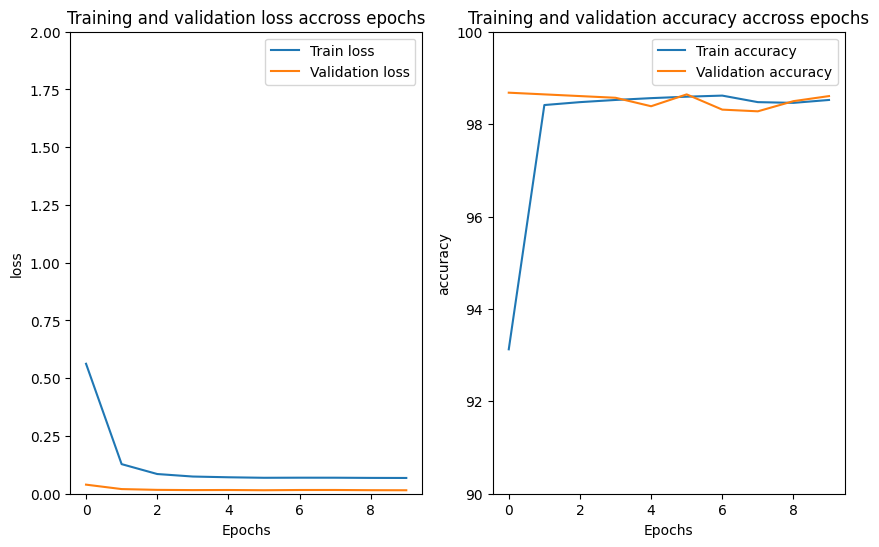

In [25]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

axs[0].plot(total_loss_train_plot, label='Train loss')
axs[0].plot(total_loss_validation_plot, label='Validation loss')
axs[0].set_title("Training and validation loss accross epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("loss")
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Train accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation accuracy')
axs[1].set_title("Training and validation accuracy accross epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("accuracy")
axs[1].set_ylim([90, 100])
axs[1].legend()

plt.show()


In [29]:
area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))

tensor([0.], device='cuda:0', grad_fn=<SigmoidBackward0>)
Class is:  0


In [28]:
original_df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='str')